# Palmer Penguins：種・体格・形状の探索

run_id: `v020-exp-03`。日本語で計画、取得、検証、結果を記録する。

In [1]:
from pathlib import Path
import sys, os, io, json, hashlib, contextlib, warnings
from datetime import datetime, timezone
from dataclasses import asdict
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
import numpy as np
import pandas as pd
from IPython.display import display, Image
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import nbformat
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, stats_analysis, visualization
from ai_data_scientist import data_definition as dd, analysis_assumptions as aa
from ai_data_scientist import data_quality as dq, sensitivity, insight_engine, notebook_audit
RUN_ID = 'v020-exp-03'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-03-penguins')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
language = language_router.detect_language('ペンギンの種や体格の違いを調べてください')
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
@contextlib.contextmanager
def phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行取消が要求されています')
    lifecycle.mark_execution_start(RUN_ID)
    phase_log.append({'phase': name, 'event': 'execution_start', 'time': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        phase_log.append({'phase': name, 'event': 'execution_end', 'time': datetime.now(timezone.utc).isoformat()})
SEED = 20261002
FEATURES = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
print('run_id:', RUN_ID, 'language:', language, 'seed:', SEED)
display(asdict(lifecycle.get_run_status(RUN_ID)))

import re
def refresh_notebook(nb):
    by_id = {c.id: c for c in nb.cells}
    for cell in nb.cells:
        if cell.cell_type == 'markdown' and 'evidence_source_id' in cell.metadata:
            evidence_cell = by_id[cell.metadata.evidence_source_id]
            text = '\n'.join(str(o.get('data', {}).get('text/plain', '')) for o in evidence_cell.outputs)
            exact_value = insight_engine.extract_cited_value({'output': text}, cell.metadata.evidence_pattern)
            fence = re.search(r'```evidence\n(.*?)\n```', cell.source, re.S)
            evidence_manifest = json.loads(fence.group(1))
            evidence_manifest.update(execution_count=evidence_cell.execution_count, cited_value=exact_value)
            cell.source = cell.source[:fence.start()] + '```evidence\n' + json.dumps(evidence_manifest, ensure_ascii=False, separators=(',', ':')) + '\n```' + cell.source[fence.end():]
        if cell.cell_type == 'code' and cell.source.startswith("with phase('初回図表"):
            cell.metadata['chart'] = chart_metadata['initial_charts']
        if cell.cell_type == 'code' and cell.source.startswith("with phase('反復1"):
            cell.metadata['chart'] = chart_metadata['iteration1_charts']
    nb.metadata['run_id'] = RUN_ID
    nb.metadata['provenance'] = provenance
    nb.metadata['insight_authoring'] = {'functions': ['insight_engine.extract_cited_value', 'insight_engine.record_insight'], 'language': language, 'evidence_binding': 'cell id + exact output pattern; execution_count refreshed after replay'}


run_id: v020-exp-03 language: ja seed: 20261002


{'run_id': 'v020-exp-03',
 'state': 'running',
 'active_cell_executions': 0,
 'pending_notebook_writes': 0,
 'locks_held': 0,
 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-03-penguins/notebooks/kaggle-v020-kaggle-exp-03-penguins.ipynb',
 'reason': None}

## 分析計画
1. Kaggle SDKで認証、検索、ファイル一覧、必要なCSV取得を行い、出典・取得日時・SHA-256を固定する。再実行時は取得済みファイルのハッシュを確認して利用する。
2. 1行の観測単位、単位、採集範囲、欠損・カテゴリ異常・重複を確認し、データ定義と分析前提をmanifestで明示する。無根拠な欠損補完や外れ値削除はしない。
3. くちばし長・深さ、フリッパー長、体重について、種別分布、形状散布図、体重との関係、種×性別集計を用いる。平均差だけでなく重なり、効果量と95%区間を示す。
4. 全体相関と種内相関を区別する。探索的な比較であり、原因・適応・個体分類の性能は主張しない。
5. 初回結果を読み直し、結論に効く未解決点だけを自然言語で追加依頼する（最大3反復）。雌雄構成、島、年、欠損処理などを必要に応じて検証する。
6. 図の実出力とメタデータを監査し、全コードセルをJupyter MCPで上から再実行後、根拠の参照を更新してnotebook_auditとライフサイクル状態を記録する。

95%区間は観測個体が独立という条件付きの探索的区間。母集団への無作為抽出・因果識別は仮定しない。乱数seedを固定する。


In [2]:
with phase('Kaggle取得'):
    slug = 'parulpandey/palmer-archipelago-antarctica-penguin-data'
    source_url = 'https://www.kaggle.com/datasets/' + slug
    query = 'palmer archipelago antarctica penguin'
    cache = data_dir / 'provenance.json'
    api_log = []
    failed_step = 'SDK import'
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            failed_step = 'authenticate'
            api.authenticate()
            failed_step = 'dataset_list'
            matches = api.dataset_list(search=query)
            refs = [str(item.ref) for item in matches]
            if slug not in refs:
                matches = api.dataset_list(search='palmer penguins')
                refs += [str(item.ref) for item in matches]
            failed_step = 'dataset_list_files'
            listing = api.dataset_list_files(slug)
            available = [item.name for item in listing.files]
            requested = [name for name in available if Path(name).name in ('penguins_size.csv', 'penguins_lter.csv')]
            if not requested:
                raise FileNotFoundError('対応CSVがありません')
            previous = json.loads(cache.read_text()) if cache.exists() else None
            failed_step = 'dataset_download_file'
            for name in requested:
                destination = data_dir / Path(name).name
                if not destination.exists():
                    api.dataset_download_file(slug, name, path=str(data_dir), force=True, quiet=True)
                zipped = data_dir / (Path(name).name + '.zip')
                if not destination.exists() and zipped.exists():
                    import zipfile
                    with zipfile.ZipFile(zipped) as archive:
                        destination.write_bytes(archive.read(name))
                if not destination.exists():
                    raise FileNotFoundError('取得したCSVが見つかりません')
        api_log = [{'step': 'authenticate', 'status': '成功'}, {'step': 'dataset_list', 'status': '成功', 'query': query, 'matched_refs': sorted(set(refs))}, {'step': 'dataset_list_files', 'status': '成功', 'files': available}]
        if previous and previous['source'] == 'Kaggle':
            provenance = previous
            for item in provenance['files']:
                assert hashlib.sha256((data_dir / item['filename']).read_bytes()).hexdigest() == item['sha256'], '取得ファイルのSHA-256が変化しました'
        else:
            provenance = {'source': 'Kaggle', 'owner_dataset_slug': slug, 'url': source_url,
                          'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
                          'files': [{'filename': Path(name).name, 'sha256': hashlib.sha256((data_dir / Path(name).name).read_bytes()).hexdigest()} for name in requested]}
    except Exception as exc:
        # 秘密を含み得る例外本文・SDK出力は保存しない。段階、型、HTTP状態だけ記録。
        failure = {'step': failed_step, 'exception_type': type(exc).__name__, 'http_status': getattr(getattr(exc, 'response', None), 'status_code', None)}
        api_log.append({'status': '失敗', **failure})
        fallback_url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv'
        white_paper = Path('/home/nahisaho/kaggle/experiments/white-paper.md').read_text()
        assert fallback_url in white_paper, '指定旧実験の公開URLが確認できません'
        import urllib.request
        previous = json.loads(cache.read_text()) if cache.exists() else None
        destination = data_dir / 'penguins.csv'
        if not destination.exists():
            with urllib.request.urlopen(fallback_url, timeout=60) as response:
                destination.write_bytes(response.read())
        provenance = previous if previous and previous['source'] == '公開CSVフォールバック' else {
            'source': '公開CSVフォールバック', 'owner_dataset_slug': None, 'requested_slug': slug,
            'url': fallback_url, 'kaggle_failure': failure,
            'fallback_reason': 'Kaggle APIで対応公開データを取得できなかったため',
            'identity_caveat': '公開CSVとKaggle掲載版の完全な同一性は保証されない',
            'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
            'files': [{'filename': 'penguins.csv', 'sha256': hashlib.sha256(destination.read_bytes()).hexdigest()}]}
    cache.write_text(json.dumps(provenance, ensure_ascii=False, indent=2))
    print('API実行ログ（トークン・例外本文なし）:')
    display(api_log)
    print('取得元・ファイル同一性:')
    display(provenance)


API実行ログ（トークン・例外本文なし）:
取得元・ファイル同一性:


[{'step': 'authenticate', 'status': '成功'},
 {'step': 'dataset_list',
  'status': '成功',
  'query': 'palmer archipelago antarctica penguin',
  'matched_refs': ['ambika4x4/palmer-penguins-dataset-for-eda',
   'djohnson2233/palmer-penguins',
   'hassaan732/penguins',
   'jacobegarcia/palmer-penguins-linked-from-seaborn-data',
   'juanagsolano/penguins-v1',
   'martinnguyen25/palmer-archipelago-antarctica-penguin-data',
   'pancaldi/palmerpenguins',
   'parulpandey/palmer-archipelago-antarctica-penguin-data',
   'pyim59/classic-datasets',
   'resulcaliskan/penguins',
   'samybaladram/palmers-penguin-dataset-extended',
   'satyajeetrai/palmer-penguins-dataset-for-eda',
   'sergeyshchelkunov/sergey-penguins',
   'subodhambade/penguin-data-simplified',
   'sudharsanisaravanan/palmer-archipelago-antarctica-penguin-data',
   'sumaya23abdul/palmer-archipelago-penguin-data',
   'utkarshx27/penguin-size-clutch-and-blood-isotope-data',
   'way2studytable/palmer-penguins-using-r']},
 {'step': 'datase

{'source': 'Kaggle',
 'owner_dataset_slug': 'parulpandey/palmer-archipelago-antarctica-penguin-data',
 'url': 'https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data',
 'retrieved_at_utc': '2026-10-01T18:10:17.764427+00:00',
 'files': [{'filename': 'penguins_lter.csv',
   'sha256': '5e625602cdd94c54167b0684c864a11ff9d1f2fb344fb5d252d33dea701a535f'},
  {'filename': 'penguins_size.csv',
   'sha256': 'aa728597b2228a2637e39c6f08e40a80971f4cdac7faf7bc21ff4481ee3e3ae9'}]}

## データ読込と意味的品質検査

範囲は生物学的異常を見逃さないための広い暫定検査であり、正しい値の保証ではない。性別の未知コードは欠損へ明示変換する。簡略表とLTER表は独立データではなく、行順を各形態値・種・島で検証したうえで採集年を補う。

In [3]:
with phase('読込・品質検査'):
    filename = 'penguins_size.csv' if provenance['source'] == 'Kaggle' else 'penguins.csv'
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(data_dir / filename)))
    original = loaded.dataframe.copy()
    df = original.rename(columns={'culmen_length_mm': 'bill_length_mm', 'culmen_depth_mm': 'bill_depth_mm'}).copy()
    df['sex_original'] = df['sex']
    df['sex'] = df['sex'].str.upper()
    raw_anomalies = dq.detect_anomalies(df, {'sex': {'allowed': ['MALE', 'FEMALE']}})
    invalid_sex = df['sex'].notna() & ~df['sex'].isin(['MALE', 'FEMALE'])
    df.loc[invalid_sex, 'sex'] = pd.NA
    lter = None
    if provenance['source'] == 'Kaggle' and (data_dir / 'penguins_lter.csv').exists():
        lter = ingestion.ingest(ingestion.SourceSpec('csv', str(data_dir / 'penguins_lter.csv'))).dataframe
        raw_names = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']
        assert len(lter) == len(df)
        for feature, raw_name in zip(FEATURES, raw_names):
            np.testing.assert_allclose(df[feature], lter[raw_name], equal_nan=True)
        assert (df['species'].to_numpy() == lter['Species'].str.split().str[0].to_numpy()).all()
        assert (df['island'].to_numpy() == lter['Island'].to_numpy()).all()
        df['year'] = pd.to_datetime(lter['Date Egg'], format='%m/%d/%y').dt.year.to_numpy()
        df['individual_id'] = lter['Individual ID'].to_numpy()
        df['clutch_completion'] = lter['Clutch Completion'].to_numpy()
    elif 'year' not in df:
        df['year'] = np.nan
    schema = {'species': {'allowed': ['Adelie', 'Chinstrap', 'Gentoo'], 'not_null': True},
              'island': {'allowed': ['Biscoe', 'Dream', 'Torgersen'], 'not_null': True},
              'sex': {'allowed': ['MALE', 'FEMALE']},
              'bill_length_mm': {'min': 20, 'max': 80}, 'bill_depth_mm': {'min': 8, 'max': 30},
              'flipper_length_mm': {'min': 140, 'max': 260}, 'body_mass_g': {'min': 1500, 'max': 8000}}
    anomalies = dq.detect_anomalies(df, schema)
    assert set(schema).issubset(df.columns), '宣言列の欠落（検査APIが欠落列を無視するため明示検査）'
    duplicate_count = int(original.duplicated().sum())
    morphology_report = cleaning.clean_dataset(df, 'drop_na', columns=FEATURES + ['species'])
    morph = morphology_report.dataframe.copy()
    sex_report = cleaning.clean_dataset(morph, 'drop_na', columns=['sex'])
    sex_df = sex_report.dataframe.copy()
    exploration = eda.explore(df)
    print('原表 shape:', original.shape, '完全一致重複:', duplicate_count)
    print('元の性別異常:'); display([asdict(a) for a in raw_anomalies])
    print('正規化後の意味的異常:'); display([asdict(a) for a in anomalies])
    print('欠損数:'); display(df.isna().sum().to_frame('欠損数'))
    print('欠損除外の影響:', {'形態': (morphology_report.rows_before, morphology_report.rows_after, morphology_report.rows_removed), '性別分析': (sex_report.rows_before, sex_report.rows_after, sex_report.rows_removed)})
    print('種・島・性別・年の構成:')
    display(df.groupby('species').size().to_frame('n'))
    display(pd.crosstab(df.species, df.island))
    display(pd.crosstab(df.species, df.sex.fillna('不明')))
    display(pd.crosstab(df.species, df.year))
    print('EDA結果:'); display(exploration)
    if lter is not None:
        print('原表の定義情報:'); display(lter[['studyName', 'Region', 'Stage', 'Date Egg', 'Comments']].head())


原表 shape: (344, 7) 完全一致重複: 0
元の性別異常:
正規化後の意味的異常:
欠損数:
欠損除外の影響: {'形態': (344, 342, 2), '性別分析': (342, 333, 9)}
種・島・性別・年の構成:
EDA結果:
原表の定義情報:


[{'column': 'sex',
  'rule': 'allowed_values',
  'row_count': 1,
  'message': "Column 'sex' has 1 value(s) not in the allowed set.",
  'row_indices': (336,)}]

[]

,欠損数
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
sex_original,10
year,0
individual_id,0


,n
species,
Adelie,152
Chinstrap,68
Gentoo,124


island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


sex,FEMALE,MALE,不明
species,,,
Adelie,73,73,6
Chinstrap,34,34,0
Gentoo,58,61,5


year,2007,2008,2009
species,,,
Adelie,50,50,52
Chinstrap,26,18,24
Gentoo,34,46,44


EDAReport(describe={'bill_length_mm': {'count': 342.0, 'mean': 43.9219298245614, 'std': 5.4595837139265315, 'min': 32.1, '25%': 39.225, '50%': 44.45, '75%': 48.5, 'max': 59.6}, 'bill_depth_mm': {'count': 342.0, 'mean': 17.151169590643278, 'std': 1.9747931568167816, 'min': 13.1, '25%': 15.6, '50%': 17.3, '75%': 18.7, 'max': 21.5}, 'flipper_length_mm': {'count': 342.0, 'mean': 200.91520467836258, 'std': 14.061713679356888, 'min': 172.0, '25%': 190.0, '50%': 197.0, '75%': 213.0, 'max': 231.0}, 'body_mass_g': {'count': 342.0, 'mean': 4201.754385964912, 'std': 801.9545356980956, 'min': 2700.0, '25%': 3550.0, '50%': 4050.0, '75%': 4750.0, 'max': 6300.0}, 'year': {'count': 344.0, 'mean': 2008.0290697674418, 'std': 0.8183559254837041, 'min': 2007.0, '25%': 2007.0, '50%': 2008.0, '75%': 2009.0, 'max': 2009.0}}, dtypes={'species': 'str', 'island': 'str', 'bill_length_mm': 'float64', 'bill_depth_mm': 'float64', 'flipper_length_mm': 'float64', 'body_mass_g': 'float64', 'sex': 'str', 'sex_original'

,studyName,Region,Stage,Date Egg,Comments
0,PAL0708,Anvers,"Adult, 1 Egg Stage",11/11/07,Not enough blood for isotopes.
1,PAL0708,Anvers,"Adult, 1 Egg Stage",11/11/07,NaN
2,PAL0708,Anvers,"Adult, 1 Egg Stage",11/16/07,NaN
3,PAL0708,Anvers,"Adult, 1 Egg Stage",11/16/07,Adult not sampled.
4,PAL0708,Anvers,"Adult, 1 Egg Stage",11/16/07,NaN


## データ定義・分析前提manifest

測定手順、ライセンス、観測独立性の未確認事項は、値や単位の確認とは区別する。独立の参照データがないためvalidate_anomaliesとcompare_datasetsは適用しない。LTER表は同じ採集表の別表示であり独立検証には使わない。

In [4]:
with phase('定義・前提manifest'):
    definition_source = 'penguins_lter.csv: 列名、Species、Region、Stage、Date Egg'
    units = {'bill_length_mm': 'mm', 'bill_depth_mm': 'mm', 'flipper_length_mm': 'mm', 'body_mass_g': 'g'}
    meanings = {'bill_length_mm': 'くちばしのculmen長（原列 Culmen Length）', 'bill_depth_mm': 'くちばしのculmen深さ（原列 Culmen Depth）', 'flipper_length_mm': 'フリッパー長', 'body_mass_g': '体重'}
    variables = {feature: {'unit': dd.FieldValue(units[feature], 'verified' if lter is not None else 'inferred', definition_source),
                            'definition': dd.FieldValue(meanings[feature], 'verified' if lter is not None else 'inferred', definition_source),
                            'measurement_protocol': dd.FieldValue(None, 'unknown', '測定器・測定部位の詳細辞書を未確認')} for feature in FEATURES}
    variables.update({'species': {'definition': dd.FieldValue('Adelie / Chinstrap / Gentoo の種ラベル', 'verified', 'CSV実値')},
                      'sex': {'definition': dd.FieldValue('MALE / FEMALE、未知コード . は欠損扱い', 'verified', 'CSV実値'), 'determination_method': dd.FieldValue(None, 'unknown')},
                      'year': {'definition': dd.FieldValue('Date Eggの日付年（測定日そのものとは限らない）', 'verified' if lter is not None else 'unknown', definition_source)}})
    definition_manifest = dd.build_manifest(
        source={'provenance': provenance, 'license': dd.FieldValue(None, 'unknown', 'ライセンス条文はAPI一覧だけでは未検証')},
        dataset_scope={'row_unit': dd.FieldValue('採集記録1行（独立個体である保証は未確認）', 'inferred', '行構造'),
                       'period': dd.FieldValue('2007–2009のDate Egg年', 'verified' if lter is not None else 'unknown', definition_source),
                       'region': dd.FieldValue('Anvers、3島', 'verified' if lter is not None else 'inferred', definition_source),
                       'stage': dd.FieldValue('Adult, 1 Egg Stage', 'verified' if lter is not None else 'unknown', definition_source)},
        variables=variables,
        transformations=('culmen列をbill列へ名称変更、単位は不変', '性別 . を欠損へ変換', '形態欠損2行のみ形態分析から除外、性別欠損は性別分析だけ除外', 'LTERと形態・種・島の行一致を検証してDate Egg年を追加'))
    assumptions_manifest = aa.AnalysisAssumptionManifest(
        analysis_scope={'target': 'この採集表の3種の形態差', 'not_target': '全南極個体・因果効果・将来分類性能'},
        assumptions=(aa.Assumption('independence', '95%区間で各行を独立観測として扱う', 'assumed', impact_if_false='区間が過度に狭くなる', conclusion_critical=True),
                     aa.Assumption('missingness', '完全ケースによる種平均の偏りは小さい', 'assumed', impact_if_false='平均差の偏り', conclusion_critical=True),
                     aa.Assumption('sex_composition', '種間差が雌雄構成の差だけではない', 'assumed', impact_if_false='種差を過大評価', conclusion_critical=True),
                     aa.Assumption('no_causality', '観察データとして関連だけ記述する', 'verified')),
        causal_scope='associational', sampling={'n': len(morph), 'seed': SEED, 'selection': '採集済み便宜標本・無作為抽出を未確認'})
    findings = aa.check_manifest(assumptions_manifest)
    print('データ定義manifest:'); display(asdict(definition_manifest))
    print('unknownフィールド:'); display([(path, asdict(value)) for path, value in definition_manifest.unresolved_fields()])
    inferred_fields = [('dataset_scope.' + key, asdict(value)) for key, value in definition_manifest.dataset_scope.items() if isinstance(value, dd.FieldValue) and value.status == 'inferred']
    inferred_fields += [('variables.' + name + '.' + key, asdict(value)) for name, fields in variables.items() for key, value in fields.items() if value.status == 'inferred']
    print('inferredフィールド（unresolved_fieldsはunknownのみ返すため別途列挙）:'); display(inferred_fields)
    print('分析前提manifest:'); display(asdict(assumptions_manifest))
    print('全finding:'); display([asdict(f) for f in findings])
    (data_dir / 'data_definition_manifest.json').write_text(json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2))


データ定義manifest:
unknownフィールド:
inferredフィールド（unresolved_fieldsはunknownのみ返すため別途列挙）:
分析前提manifest:
全finding:


{'source': {'provenance': {'source': 'Kaggle',
   'owner_dataset_slug': 'parulpandey/palmer-archipelago-antarctica-penguin-data',
   'url': 'https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data',
   'retrieved_at_utc': '2026-10-01T18:10:17.764427+00:00',
   'files': [{'filename': 'penguins_lter.csv',
     'sha256': '5e625602cdd94c54167b0684c864a11ff9d1f2fb344fb5d252d33dea701a535f'},
    {'filename': 'penguins_size.csv',
     'sha256': 'aa728597b2228a2637e39c6f08e40a80971f4cdac7faf7bc21ff4481ee3e3ae9'}]},
  'license': {'value': None,
   'status': 'unknown',
   'source': 'ライセンス条文はAPI一覧だけでは未検証'}},
 'dataset_scope': {'row_unit': {'value': '採集記録1行（独立個体である保証は未確認）',
   'status': 'inferred',
   'source': '行構造'},
  'period': {'value': '2007–2009のDate Egg年',
   'status': 'verified',
   'source': 'penguins_lter.csv: 列名、Species、Region、Stage、Date Egg'},
  'region': {'value': 'Anvers、3島',
   'status': 'verified',
   'source': 'penguins_lter.csv: 列名、Species、Region、St

[('source.license',
  {'value': None, 'status': 'unknown', 'source': 'ライセンス条文はAPI一覧だけでは未検証'}),
 ('variables.bill_length_mm.measurement_protocol',
  {'value': None, 'status': 'unknown', 'source': '測定器・測定部位の詳細辞書を未確認'}),
 ('variables.bill_depth_mm.measurement_protocol',
  {'value': None, 'status': 'unknown', 'source': '測定器・測定部位の詳細辞書を未確認'}),
 ('variables.flipper_length_mm.measurement_protocol',
  {'value': None, 'status': 'unknown', 'source': '測定器・測定部位の詳細辞書を未確認'}),
 ('variables.body_mass_g.measurement_protocol',
  {'value': None, 'status': 'unknown', 'source': '測定器・測定部位の詳細辞書を未確認'}),
 ('variables.sex.determination_method',
  {'value': None, 'status': 'unknown', 'source': None})]

[('dataset_scope.row_unit',
  {'value': '採集記録1行（独立個体である保証は未確認）', 'status': 'inferred', 'source': '行構造'})]

{'analysis_scope': {'target': 'この採集表の3種の形態差',
  'not_target': '全南極個体・因果効果・将来分類性能'},
 'assumptions': ({'id': 'independence',
   'statement': '95%区間で各行を独立観測として扱う',
   'status': 'assumed',
   'evidence_cell': None,
   'impact_if_false': '区間が過度に狭くなる',
   'conclusion_critical': True},
  {'id': 'missingness',
   'statement': '完全ケースによる種平均の偏りは小さい',
   'status': 'assumed',
   'evidence_cell': None,
   'impact_if_false': '平均差の偏り',
   'conclusion_critical': True},
  {'id': 'sex_composition',
   'statement': '種間差が雌雄構成の差だけではない',
   'status': 'assumed',
   'evidence_cell': None,
   'impact_if_false': '種差を過大評価',
   'conclusion_critical': True},
  {'id': 'no_causality',
   'statement': '観察データとして関連だけ記述する',
   'status': 'verified',
   'evidence_cell': None,
   'impact_if_false': None,
   'conclusion_critical': False}),
 'causal_scope': 'associational',
 'sampling': {'n': 342, 'seed': 20261002, 'selection': '採集済み便宜標本・無作為抽出を未確認'}}

[{'code': 'unresolved_conclusion_critical_assumption',
  'severity': 'warning',
  'message': "Conclusion-critical assumption 'independence' has status 'assumed', not verified/tested.",
  'assumption_id': 'independence'},
 {'code': 'unresolved_conclusion_critical_assumption',
  'severity': 'warning',
  'message': "Conclusion-critical assumption 'missingness' has status 'assumed', not verified/tested.",
  'assumption_id': 'missingness'},
 {'code': 'unresolved_conclusion_critical_assumption',
  'severity': 'warning',
  'message': "Conclusion-critical assumption 'sex_composition' has status 'assumed', not verified/tested.",
  'assumption_id': 'sex_composition'}]

## 初回分析：種間差と体格の関連

η²は各特徴の分散のうち種別平均差が占める割合。単変量比較であり、特性間の冗長性、因果、未知個体分類精度は示さない。区間は独立性条件付き・多重比較未補正で、差の規模と分布の重なりを重視する。

In [5]:
with phase('初回集計・効果量・相関'):
    species_order = ['Adelie', 'Chinstrap', 'Gentoo']
    summary = morph.groupby('species')[FEATURES].agg(['count', 'mean', 'std', 'median'])
    print('種別特徴（個体数・平均・SD・中央値）:'); display(summary.round(3))
    eta_rows = []
    for feature in FEATURES:
        overall_mean = morph[feature].mean()
        between = sum(len(g) * (g[feature].mean() - overall_mean)**2 for _, g in morph.groupby('species'))
        total = ((morph[feature] - overall_mean)**2).sum()
        eta_rows.append({'feature': feature, 'eta_squared_species': between / total})
    eta_table = pd.DataFrame(eta_rows).sort_values('eta_squared_species', ascending=False)
    print('種ラベルで説明される分散割合η²（標本内、分類性能ではない）:'); display(eta_table.round(6))
    from itertools import combinations
    def welch_difference(a, b):
        a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
        difference = a.mean() - b.mean()
        va, vb = a.var(ddof=1)/len(a), b.var(ddof=1)/len(b)
        se = np.sqrt(va + vb)
        dof = (va + vb)**2 / (va**2/(len(a)-1) + vb**2/(len(b)-1))
        margin = stats.t.ppf(.975, dof) * se
        pooled_sd = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
        hedges_g = difference / pooled_sd * (1 - 3/(4*(len(a)+len(b))-9))
        return {'difference': difference, 'ci_low': difference-margin, 'ci_high': difference+margin, 'hedges_g': hedges_g}
    comparisons = []
    for feature in FEATURES:
        for first, second in combinations(species_order, 2):
            comparisons.append({'feature': feature, 'contrast': second + ' - ' + first, **welch_difference(morph.loc[morph.species.eq(second), feature], morph.loc[morph.species.eq(first), feature])})
    pairwise = pd.DataFrame(comparisons)
    print('種間平均差・探索的95% Welch区間（多重比較補正なし）:'); display(pairwise.round(4))
    corr_rows = []
    for label, subset in [('全体', morph)] + list(morph.groupby('species')):
        for feature in FEATURES[:-1]:
            result = stats_analysis.correlation(subset, feature, 'body_mass_g', language=language)
            corr_rows.append({'group': label, 'feature': feature, 'n': len(subset), 'r': result.statistic, 'p': result.p_value})
    corr_table = pd.DataFrame(corr_rows)
    global_correlation = stats_analysis.correlation(morph, 'flipper_length_mm', 'body_mass_g', language=language)
    display(corr_table.round(6))
    print('全体フリッパー×体重の解釈:', global_correlation.interpretation)
    print('EVIDENCE_INITIAL=' + json.dumps({'n_morph': len(morph), 'gentoo_mass_mean_g': round(morph.loc[morph.species.eq('Gentoo'), 'body_mass_g'].mean(), 6), 'global_flipper_mass_r': round(global_correlation.statistic, 6), 'eta': dict(zip(eta_table.feature, eta_table.eta_squared_species.round(6)))}, ensure_ascii=False, sort_keys=True))


種別特徴（個体数・平均・SD・中央値）:
種ラベルで説明される分散割合η²（標本内、分類性能ではない）:
種間平均差・探索的95% Welch区間（多重比較補正なし）:
全体フリッパー×体重の解釈: 相関係数は 0.8712 (p=4.371e-107) で、強い正の相関が見られます。
EVIDENCE_INITIAL={"eta": {"bill_depth_mm": 0.679759, "bill_length_mm": 0.707809, "body_mass_g": 0.669672, "flipper_length_mm": 0.778229}, "gentoo_mass_mean_g": 5076.01626, "global_flipper_mass_r": 0.871202, "n_morph": 342}


bill_length_mm                       bill_depth_mm                 \
                   count    mean    std median         count    mean    std   
species                                                                       
Adelie               151  38.791  2.663  38.80           151  18.346  1.217   
Chinstrap             68  48.834  3.339  49.55            68  18.421  1.135   
Gentoo               123  47.505  3.082  47.30           123  14.982  0.981   

                 flipper_length_mm                        body_mass_g  \
          median             count     mean    std median       count   
species                                                                 
Adelie     18.40               151  189.954  6.539  190.0         151   
Chinstrap  18.45                68  195.824  7.132  196.0          68   
Gentoo     15.00               123  217.187  6.485  216.0         123   

                                      
               mean      std  median  
species                               
Adelie     3700.662  458.566  3700.0  
Chinstrap  3733.088  384.335  3700.0  
Gentoo     5076.016  504.116  5000.0

,feature,eta_squared_species
2,flipper_length_mm,0.778229
0,bill_length_mm,0.707809
1,bill_depth_mm,0.679759
3,body_mass_g,0.669672


,feature,contrast,difference,ci_low,ci_high,hedges_g
0,bill_length_mm,Chinstrap - Adelie,10.0424,9.1319,10.9529,3.4641
1,bill_length_mm,Gentoo - Adelie,8.7135,8.0193,9.4077,3.0397
2,bill_length_mm,Gentoo - Chinstrap,-1.3289,-2.3006,-0.3573,-0.4168
3,bill_depth_mm,Chinstrap - Adelie,0.0742,-0.2611,0.4096,0.0621
4,bill_depth_mm,Gentoo - Adelie,-3.3642,-3.6257,-3.1028,-3.0030
5,bill_depth_mm,Gentoo - Chinstrap,-3.4385,-3.7625,-3.1145,-3.2979
6,flipper_length_mm,Chinstrap - Adelie,5.8699,3.8592,7.8805,0.8694
7,flipper_length_mm,Gentoo - Adelie,27.2333,25.6765,28.7902,4.1685
8,flipper_length_mm,Gentoo - Chinstrap,21.3635,19.2977,23.4292,3.1658
9,body_mass_g,Chinstrap - Adelie,32.4260,-85.5328,150.3848,0.0739


,group,feature,n,r,p
0,全体,bill_length_mm,342,0.595110,0.000000
1,全体,bill_depth_mm,342,-0.471916,0.000000
2,全体,flipper_length_mm,342,0.871202,0.000000
3,Adelie,bill_length_mm,151,0.548866,0.000000
4,Adelie,bill_depth_mm,151,0.576138,0.000000
5,Adelie,flipper_length_mm,151,0.468202,0.000000
6,Chinstrap,bill_length_mm,68,0.513638,0.000007
7,Chinstrap,bill_depth_mm,68,0.604498,0.000000
8,Chinstrap,flipper_length_mm,68,0.641559,0.000000
9,Gentoo,bill_length_mm,123,0.669166,0.000000


## 相関の日本語解釈

全体のフリッパー長×体重は「相関係数0.8712、強い正の相関」。ただし種内では0.4682–0.7027、種×性別調整後は反復1で検証する。くちばし深さ×体重の全体負相関は、種内の正相関とは逆。種の混合を個体の因果法則として読まない。正確な値・p値は直前の実行済み相関表を参照。

描画時Glyph警告: []


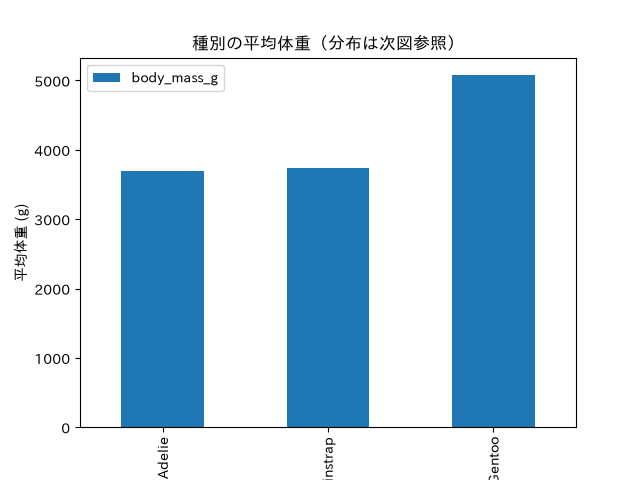

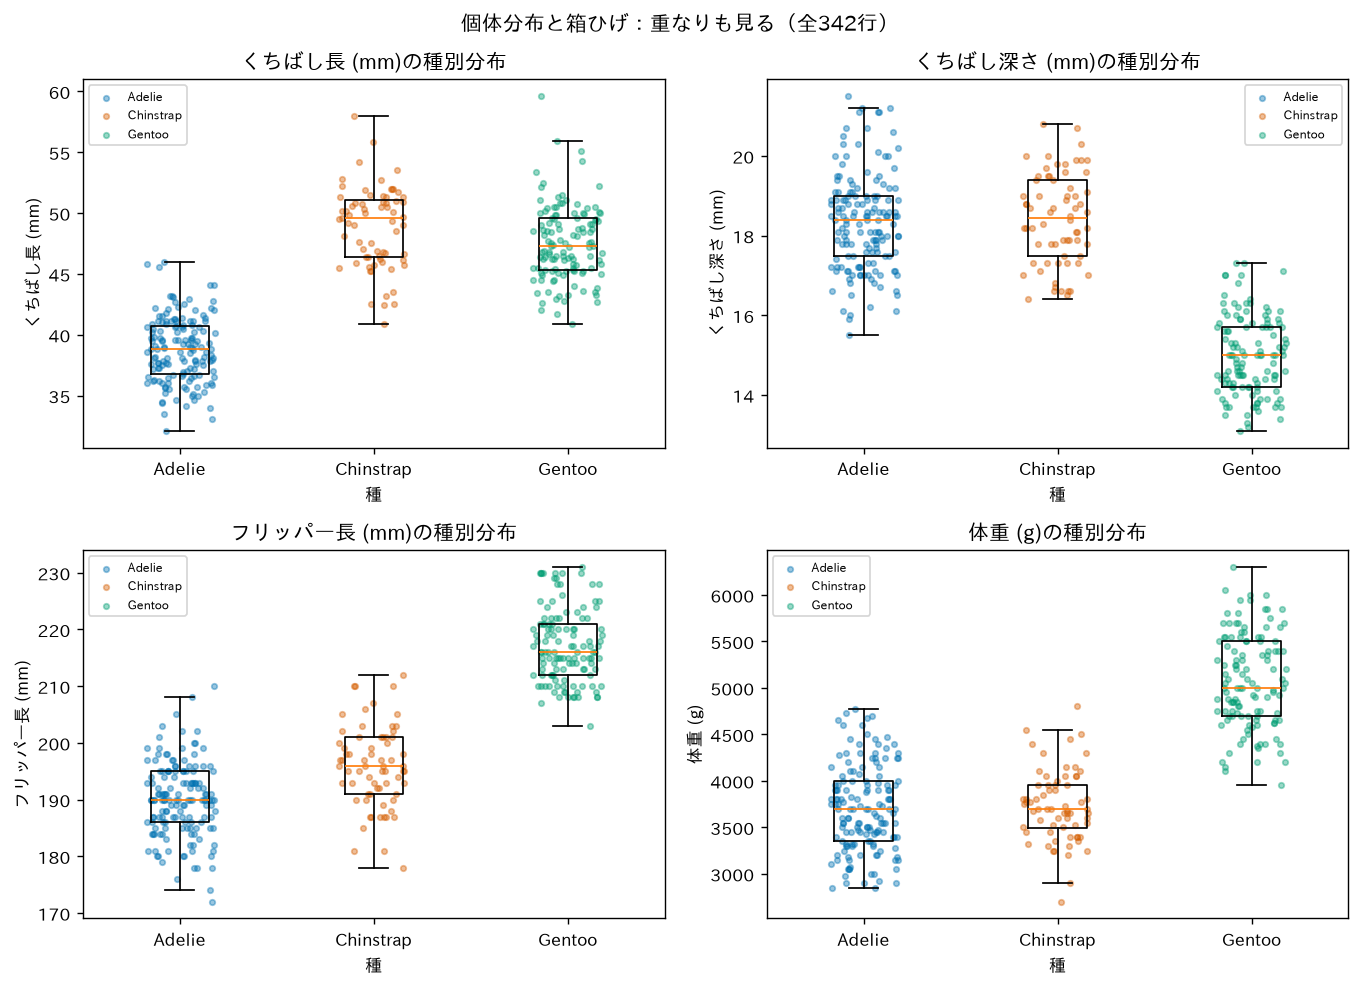

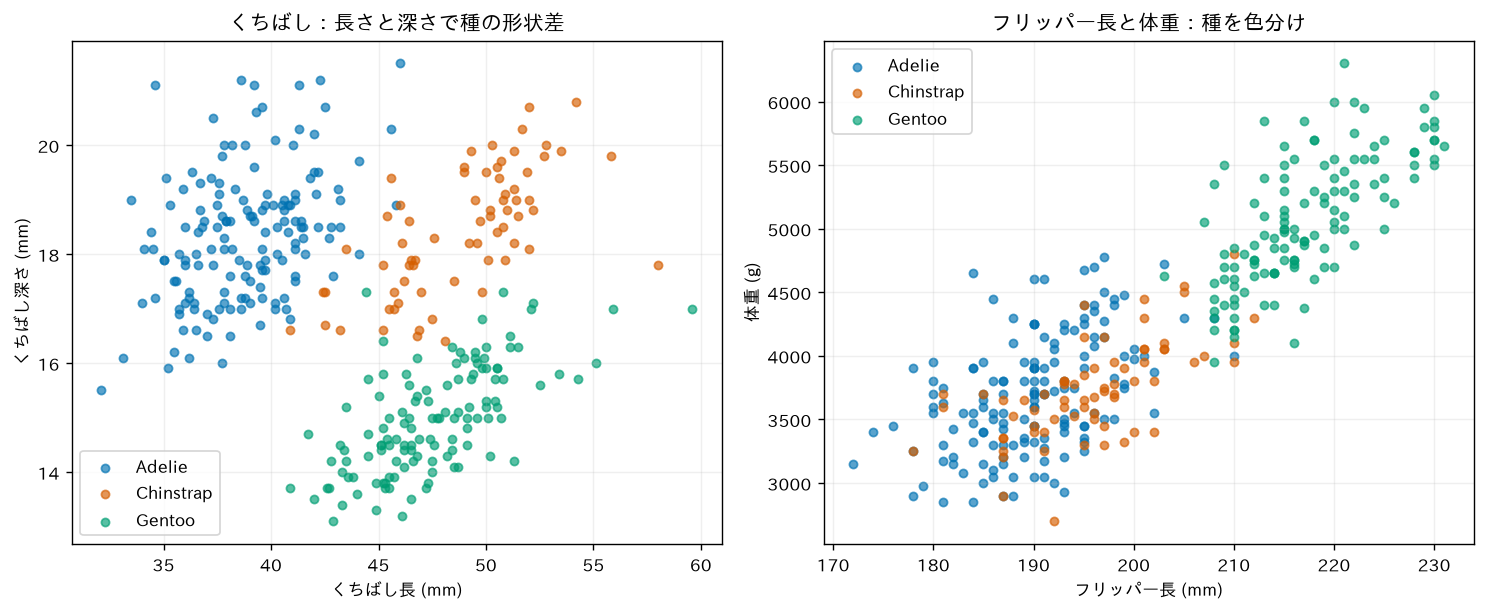

In [6]:
with phase('初回図表'):
    chart_metadata = {}
    mass_means = morph.groupby('species', sort=False)['body_mass_g'].mean().reindex(species_order).reset_index()
    png = visualization.render_chart(mass_means, kind='bar', x='species', y='body_mass_g', title='種別の平均体重（分布は次図参照）', xlabel='種', ylabel='平均体重 (g)')
    display(visualization.build_image_output(png).data, raw=True)
    labels = {'bill_length_mm': 'くちばし長 (mm)', 'bill_depth_mm': 'くちばし深さ (mm)', 'flipper_length_mm': 'フリッパー長 (mm)', 'body_mass_g': '体重 (g)'}
    colors = {'Adelie': '#0072B2', 'Chinstrap': '#D55E00', 'Gentoo': '#009E73'}
    glyph_logs = []
    def emit_figure(fig):
        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter('always')
            buf = io.BytesIO()
            fig.savefig(buf, format='png', dpi=125, bbox_inches='tight')
        glyph_logs.extend(str(w.message) for w in captured if 'Glyph' in str(w.message))
        display(visualization.build_image_output(buf.getvalue()).data, raw=True)
        plt.close(fig)
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, feature in zip(axes.flat, FEATURES):
        groups = [morph.loc[morph.species.eq(s), feature].to_numpy() for s in species_order]
        ax.boxplot(groups, tick_labels=species_order, showfliers=False)
        rng = np.random.default_rng(SEED)
        for position, species in enumerate(species_order, 1):
            values = groups[position-1]
            ax.scatter(position + rng.uniform(-.18, .18, len(values)), values, s=10, alpha=.4, c=colors[species], label=species)
        ax.set(title=labels[feature] + 'の種別分布', xlabel='種', ylabel=labels[feature])
        ax.legend(fontsize=7)
    fig.suptitle('個体分布と箱ひげ：重なりも見る（全342行）')
    fig.tight_layout()
    emit_figure(fig)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for species in species_order:
        sub = morph.loc[morph.species.eq(species)]
        axes[0].scatter(sub.bill_length_mm, sub.bill_depth_mm, s=22, alpha=.65, c=colors[species], label=species)
        axes[1].scatter(sub.flipper_length_mm, sub.body_mass_g, s=22, alpha=.65, c=colors[species], label=species)
    axes[0].set(title='くちばし：長さと深さで種の形状差', xlabel=labels['bill_length_mm'], ylabel=labels['bill_depth_mm'])
    axes[1].set(title='フリッパー長と体重：種を色分け', xlabel=labels['flipper_length_mm'], ylabel=labels['body_mass_g'])
    for ax in axes:
        ax.legend(); ax.grid(alpha=.2)
    fig.tight_layout(); emit_figure(fig)
    chart_metadata['initial_charts'] = {'title': '種別平均、4特徴分布、形状・体格散布図', 'xlabel': '種 / くちばし長(mm) / フリッパー長(mm)', 'ylabel': '特徴値(mm,g) / 深さ(mm) / 体重(g)', 'legend': species_order, 'missing_glyphs': glyph_logs}
    print('描画時Glyph警告:', glyph_logs)


**初回Insight：種差は体格とくちばし形状の両方に表れる。** Gentooは平均体重約5,076 g、フリッパー長217.19 mmで最大だが、くちばし深さは14.98 mmと最小。Adelieはくちばし長38.79 mmで短く、Chinstrapは48.83 mmと長い。フリッパー長の種別η²は0.778229で4特徴中最大。ただし2種ずつの分布には重なりがあり、体重だけではAdelieとChinstrapを区別しにくい。根拠は直前の種別集計・η²・平均差表および分布図。

```evidence
{"execution_count":5,"cited_value":"0.778229","claim_type":"descriptive"}
```

**初回Insight：全体相関を個体内の法則と解釈してはいけない。** くちばし深さ×体重は全体r=-0.471916だが、種内ではAdelie 0.576138、Chinstrap 0.604498、Gentoo 0.719085と全て正。大きいGentooの浅いくちばしが全体の負相関を作る、Simpson型の混合現象がある。フリッパー×体重も全体0.871202に対し種内0.468202–0.702667。単純な全体相関だけでは種内の体格関係を過大評価する。原因は断定しない。

```evidence
{"execution_count":5,"cited_value":"-0.471916","claim_type":"associational"}
```

## 反復依頼履歴：反復1

### 追加依頼原文
種や雌雄の混合で相関や平均差が見かけ上生じていないか確認してください。種別の雌雄差と95%区間を示し、雌雄を等重みにした種平均、種×性別内の相関、種と性別を調整した相関を比較してください。さらに体重が重なる範囲だけでもGentooの浅いくちばしとAdelieの短いくちばしが残るか調べてください。

### 選定理由
全体の負相関が全種内で正になること、種内の体格分布に雌雄が混在することが未解決。単なる全体比較では体格の意味を誤るため実施。

雄−雌：平均差と95%区間
雌雄を50:50にした種平均
種×性別内の相関
種×性別の群平均を除いた残差相関
3種の体重レンジ交差: 3950.0 4775.0
共通体重範囲・性別調整後の形状差（基準Adelie、共通傾き仮定）
注意：残差相関も因果ではない。共通体重範囲は雄Gentoo・雌Adelieなど構成が偏り、共通傾きモデルは探索的。


bill_length_mm                bill_depth_mm                 \
                          count    mean    std         count    mean    std   
species   sex                                                                 
Adelie    FEMALE             73  37.258  2.029            73  17.622  0.943   
          MALE               73  40.390  2.277            73  19.073  1.019   
Chinstrap FEMALE             34  46.574  3.109            34  17.588  0.781   
          MALE               34  51.094  1.565            34  19.253  0.761   
Gentoo    FEMALE             58  45.564  2.051            58  14.238  0.540   
          MALE               61  49.474  2.721            61  15.718  0.741   

                 flipper_length_mm                 body_mass_g            \
                             count     mean    std       count      mean   
species   sex                                                              
Adelie    FEMALE                73  187.795  5.595          73  3368.836   
          MALE                  73  192.411  6.599          73  4043.493   
Chinstrap FEMALE                34  191.735  5.754          34  3527.206   
          MALE                  34  199.912  5.977          34  3938.971   
Gentoo    FEMALE                58  212.707  3.898          58  4679.741   
          MALE                  61  221.541  5.673          61  5484.836   

                           
                      std  
species   sex              
Adelie    FEMALE  269.380  
          MALE    346.812  
Chinstrap FEMALE  285.334  
          MALE    362.138  
Gentoo    FEMALE  281.578  
          MALE    313.159

,species,feature,difference,ci_low,ci_high,hedges_g
0,Adelie,bill_length_mm,3.1329,2.4272,3.8385,1.4451
1,Adelie,bill_depth_mm,1.4507,1.1295,1.7719,1.4701
2,Adelie,flipper_length_mm,4.6164,2.6144,6.6184,0.7507
3,Adelie,body_mass_g,674.6575,573.0139,776.3012,2.1613
4,Chinstrap,bill_length_mm,4.5206,3.3210,5.7202,1.8160
5,Chinstrap,bill_depth_mm,1.6647,1.2912,2.0382,2.1338
6,Chinstrap,flipper_length_mm,8.1765,5.3357,11.0173,1.3779
7,Chinstrap,body_mass_g,411.7647,253.7391,569.7903,1.2487
8,Gentoo,bill_length_mm,3.9100,3.0375,4.7825,1.6068
9,Gentoo,bill_depth_mm,1.4801,1.2453,1.7149,2.2589


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.824,18.347,190.103,3706.164
Chinstrap,48.834,18.421,195.824,3733.088
Gentoo,47.519,14.978,217.124,5082.289


,species,sex,feature,n,r
0,Adelie,FEMALE,bill_depth_mm,73,0.396937
1,Adelie,FEMALE,flipper_length_mm,73,0.262930
2,Adelie,MALE,bill_depth_mm,73,0.159558
3,Adelie,MALE,flipper_length_mm,73,0.360434
4,Chinstrap,FEMALE,bill_depth_mm,34,0.391344
5,Chinstrap,FEMALE,flipper_length_mm,34,0.242150
6,Chinstrap,MALE,bill_depth_mm,34,0.345404
7,Chinstrap,MALE,flipper_length_mm,34,0.664588
8,Gentoo,FEMALE,bill_depth_mm,58,0.371881
9,Gentoo,FEMALE,flipper_length_mm,58,0.487618


,feature,r_residual_species_sex
0,bill_length_mm,0.259107
1,bill_depth_mm,0.285439
2,flipper_length_mm,0.374451


bill_length_mm         bill_depth_mm         flipper_length_mm  \
                   count    mean         count    mean             count   
species                                                                    
Adelie                44  40.968            44  19.200                44   
Chinstrap             19  50.795            19  19.242                19   
Gentoo                37  45.297            37  14.154                37   

                   body_mass_g            
              mean       count      mean  
species                                   
Adelie     194.591          44  4263.068  
Chinstrap  202.842          19  4157.895  
Gentoo     211.676          37  4516.892

,feature,coefficient,difference_mm,ci_low,ci_high,n
0,bill_length_mm,C(species)[T.Chinstrap],10.4694,9.3078,11.6310,100
1,bill_length_mm,C(species)[T.Gentoo],9.1155,7.2870,10.9441,100
2,bill_depth_mm,C(species)[T.Chinstrap],0.1961,-0.2638,0.6559,100
3,bill_depth_mm,C(species)[T.Gentoo],-4.3710,-5.1940,-3.5480,100


'EVIDENCE_ITER1={"balanced_gentoo_minus_adelie_g": 1376.124339, "male_minus_female_g": {"Adelie": 674.657534, "Chinstrap": 411.764706, "Gentoo": 805.094686}, "residual_correlations": {"bill_depth_mm": 0.285439, "bill_length_mm": 0.259107, "flipper_length_mm": 0.374451}}'

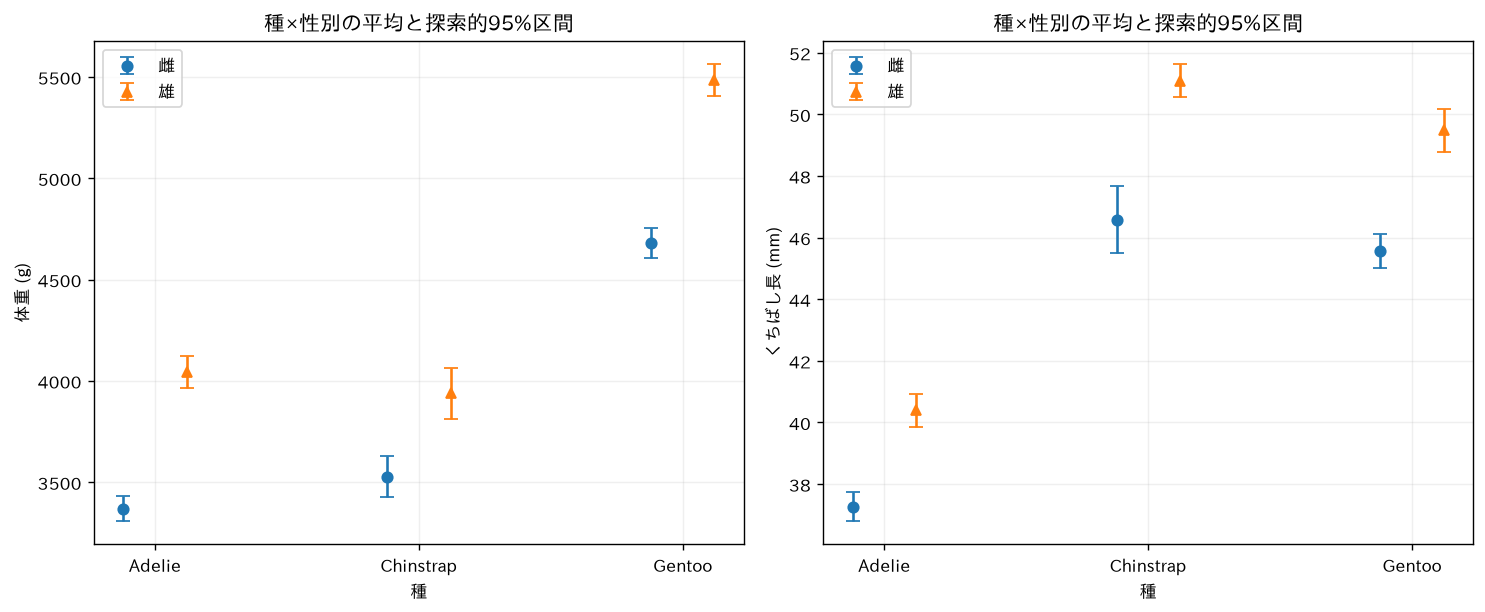

In [7]:
with phase('反復1・雌雄と混合関係'):
    sex_summary = sex_df.groupby(['species', 'sex'])[FEATURES].agg(['count', 'mean', 'std'])
    display(sex_summary.round(3))
    sex_differences = []
    for species, subset in sex_df.groupby('species'):
        for feature in FEATURES:
            sex_differences.append({'species': species, 'feature': feature, **welch_difference(subset.loc[subset.sex.eq('MALE'), feature], subset.loc[subset.sex.eq('FEMALE'), feature])})
    sex_difference_table = pd.DataFrame(sex_differences)
    print('雄−雌：平均差と95%区間'); display(sex_difference_table.round(4))
    balanced_means = sex_df.groupby(['species', 'sex'])[FEATURES].mean().groupby('species').mean()
    print('雌雄を50:50にした種平均'); display(balanced_means.round(3))
    within_rows = []
    for (species, sex), subset in sex_df.groupby(['species', 'sex']):
        for feature in ['bill_depth_mm', 'flipper_length_mm']:
            r = stats_analysis.correlation(subset, feature, 'body_mass_g', language=language)
            within_rows.append({'species': species, 'sex': sex, 'feature': feature, 'n': len(subset), 'r': r.statistic})
    within_sex = pd.DataFrame(within_rows)
    print('種×性別内の相関'); display(within_sex.round(6))
    adjusted_correlations = []
    for feature in FEATURES[:-1]:
        rx = smf.ols(feature + ' ~ C(species) * C(sex)', data=sex_df).fit().resid
        ry = smf.ols('body_mass_g ~ C(species) * C(sex)', data=sex_df).fit().resid
        adjusted_correlations.append({'feature': feature, 'r_residual_species_sex': stats.pearsonr(rx, ry).statistic})
    print('種×性別の群平均を除いた残差相関'); display(pd.DataFrame(adjusted_correlations).round(6))
    common_low = sex_df.groupby('species').body_mass_g.min().max()
    common_high = sex_df.groupby('species').body_mass_g.max().min()
    overlap = sex_df.loc[sex_df.body_mass_g.between(common_low, common_high)].copy()
    print('3種の体重レンジ交差:', common_low, common_high)
    display(overlap.groupby('species')[FEATURES].agg(['count', 'mean']).round(3))
    shape_coefficients = []
    shape_models = {}
    for feature in ['bill_length_mm', 'bill_depth_mm']:
        model = smf.ols(feature + ' ~ body_mass_g + C(species) + C(sex)', data=overlap).fit(cov_type='HC3')
        shape_models[feature] = model
        for name in model.params.index:
            if name.startswith('C(species)'):
                ci = model.conf_int().loc[name]
                shape_coefficients.append({'feature': feature, 'coefficient': name, 'difference_mm': model.params[name], 'ci_low': ci.iloc[0], 'ci_high': ci.iloc[1], 'n': int(model.nobs)})
    print('共通体重範囲・性別調整後の形状差（基準Adelie、共通傾き仮定）'); display(pd.DataFrame(shape_coefficients).round(4))
    balanced_gap = float(balanced_means.loc['Gentoo', 'body_mass_g'] - balanced_means.loc['Adelie', 'body_mass_g'])
    print('注意：残差相関も因果ではない。共通体重範囲は雄Gentoo・雌Adelieなど構成が偏り、共通傾きモデルは探索的。')
    display('EVIDENCE_ITER1=' + json.dumps({'balanced_gentoo_minus_adelie_g': round(balanced_gap, 6), 'male_minus_female_g': dict(zip(sex_difference_table.loc[sex_difference_table.feature.eq('body_mass_g'), 'species'], sex_difference_table.loc[sex_difference_table.feature.eq('body_mass_g'), 'difference'].round(6))), 'residual_correlations': {x['feature']: round(x['r_residual_species_sex'], 6) for x in adjusted_correlations}}, sort_keys=True))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, feature in zip(axes, ['body_mass_g', 'bill_length_mm']):
        for sex, shift, marker in [('FEMALE', -.12, 'o'), ('MALE', .12, '^')]:
            means, lower, upper = [], [], []
            for species in species_order:
                values = sex_df.loc[sex_df.species.eq(species) & sex_df.sex.eq(sex), feature]
                mean = values.mean(); margin = stats.t.ppf(.975, len(values)-1) * values.std(ddof=1)/np.sqrt(len(values))
                means.append(mean); lower.append(margin); upper.append(margin)
            ax.errorbar(np.arange(3)+shift, means, yerr=[lower, upper], fmt=marker, capsize=4, label='雌' if sex == 'FEMALE' else '雄')
        ax.set_xticks(np.arange(3), species_order)
        ax.set(title='種×性別の平均と探索的95%区間', xlabel='種', ylabel=labels[feature]); ax.legend(); ax.grid(alpha=.2)
    fig.tight_layout(); emit_figure(fig)
    chart_metadata['iteration1_charts'] = {'title': '種×性別の平均と探索的95%区間', 'xlabel': '種', 'ylabel': '体重(g) / くちばし長(mm)', 'legend': ['雌', '雄'], 'missing_glyphs': list(glyph_logs)}


**反復1の結果・証拠：雌雄差は大きいが、種差を消さない。** 雄−雌の体重差はAdelie約675 g（95%区間573–776）、Chinstrap約412 g（254–570）、Gentoo約805 g（697–913）。雌雄等重みでもGentoo−Adelieは1,376.124339 g。種×性別調整後のフリッパー×体重相関は0.374451、深さ×体重は0.285439で、全体相関より弱い。共通体重範囲3,950–4,775 gの100行でも、性別と体重を調整するとGentooの深さはAdelieより約4.37 mm浅く、Chinstrapの長さは約10.47 mm長い。残る限界：重なり範囲の雌雄構成が偏り、共通傾きと独立性に条件付けたモデルであり、因果効果ではない。根拠は反復1の雌雄平均差・残差相関・共通範囲モデル表。

```evidence
{"execution_count":7,"cited_value":"{\"balanced_gentoo_minus_adelie_g\": 1376.124339, \"male_minus_female_g\": {\"Adelie\": 674.657534, \"Chinstrap\": 411.764706, \"Gentoo\": 805.094686}, \"residual_correlations\": {\"bill_depth_mm\": 0.285439, \"bill_length_mm\": 0.259107, \"flipper_length_mm\": 0.374451}}","claim_type":"associational"}
```

## 反復依頼履歴：反復2

### 追加依頼原文
Gentooの大きな体格とくちばしの種差が、島・採集年・欠損処理・少数の極端値に依存していないか確認してください。同じ島にいる種同士を性別と年を調整して比較し、平均・中央値・10%トリム平均、性別欠損を含めるか否か、年の除外を組み合わせた感度分析を実施してください。欠測値と未知性別の割当てを変えた場合の結論の変動も示してください。

### 選定理由
雌雄を揃えても差が残るがGentooはBiscoeのみ、ChinstrapはDreamのみ。島と種の交絡、年、欠損除外、中心統計量への依存を確認する価値がある。20%の感度閾値は分析上の判断であり有意性の基準ではない。

In [8]:
with phase('反復2・島年欠損感度'):
    matched_rows = []
    for island, candidate in [('Biscoe', 'Gentoo'), ('Dream', 'Chinstrap')]:
        subset = sex_df.loc[sex_df.island.eq(island) & sex_df.species.isin(['Adelie', candidate])].copy()
        for feature in FEATURES:
            model = smf.ols(feature + ' ~ C(species) + C(sex) + C(year)', data=subset).fit(cov_type='HC3')
            term = 'C(species)[T.' + candidate + ']'
            ci = model.conf_int().loc[term]
            matched_rows.append({'island': island, 'contrast': candidate + ' - Adelie', 'feature': feature, 'n': int(model.nobs), 'difference': model.params[term], 'ci_low': ci.iloc[0], 'ci_high': ci.iloc[1]})
    matched_table = pd.DataFrame(matched_rows)
    print('同島内、性別・年調整比較（HC3、共通加算効果仮定）'); display(matched_table.round(4))
    centers = {'mean': np.mean, 'median': np.median, 'trim10': lambda values: stats.trim_mean(values, .1)}
    plan2 = sensitivity.SensitivityPlan(parameter_grid={'center': ['mean', 'median', 'trim10'], 'cases': ['morph', 'known_sex'], 'omit_year': [None, 2007, 2008, 2009]}, max_runs=24)
    def subset2(cases, omit_year):
        sub = morph if cases == 'morph' else sex_df
        return sub if omit_year is None else sub.loc[sub.year.ne(omit_year)]
    sensitivity_reports = {}
    sensitivity_details = []
    for label, feature, first, second in [('Gentoo-Adelie体重', 'body_mass_g', 'Gentoo', 'Adelie'), ('Gentoo-Adelieフリッパー', 'flipper_length_mm', 'Gentoo', 'Adelie'), ('Gentoo-Adelie深さ', 'bill_depth_mm', 'Gentoo', 'Adelie'), ('Chinstrap-Adelie長さ', 'bill_length_mm', 'Chinstrap', 'Adelie')]:
        def analysis_fn(center, cases, omit_year):
            sub = subset2(cases, omit_year)
            return centers[center](sub.loc[sub.species.eq(first), feature]) - centers[center](sub.loc[sub.species.eq(second), feature])
        report = sensitivity.run_sensitivity(plan2, analysis_fn, stability_tolerance=.2)
        sensitivity_reports[label] = report
        values = [r.value for r in report.results]
        sensitivity_details.append({'contrast': label, 'runs': len(values), 'baseline': report.baseline_value, 'min': min(values), 'max': max(values), 'stable': report.stable, 'max_relative_deviation': report.max_relative_deviation, 'same_sign': all(np.sign(v) == np.sign(report.baseline_value) for v in values)})
    sensitivity_table = pd.DataFrame(sensitivity_details)
    print('24仕様×4対象の感度結果：stableは差の方向でなく基準から20%以内の変動という定義'); display(sensitivity_table.round(6))
    sensitivity_all = {name: asdict(report) for name, report in sensitivity_reports.items()}
    (data_dir / 'sensitivity_results.json').write_text(json.dumps(sensitivity_all, ensure_ascii=False, indent=2))
    display(pd.DataFrame([{'contrast': name, **r.specification, 'value': r.value} for name, report in sensitivity_reports.items() for r in report.results]).round(6))
    mass_bounds = []
    for bound_kind in ['observed_species_range', 'broad_semantic_range']:
        bounds = {}
        for species in ['Adelie', 'Gentoo']:
            values = df.loc[df.species.eq(species), 'body_mass_g']
            low, high = (values.min(), values.max()) if bound_kind == 'observed_species_range' else (1500., 8000.)
            missing = values.isna().sum()
            bounds[species] = ((values.sum()+missing*low)/len(values), (values.sum()+missing*high)/len(values))
        mass_bounds.append({'assumption': bound_kind, 'gentoo_minus_adelie_low_g': bounds['Gentoo'][0]-bounds['Adelie'][1], 'gentoo_minus_adelie_high_g': bounds['Gentoo'][1]-bounds['Adelie'][0]})
    print('形態欠測2行の体重だけを上下限に置いたシナリオ（実データは補完しない）'); display(pd.DataFrame(mass_bounds).round(4))
    assignment_rows = []
    for assignment in ['FEMALE', 'MALE']:
        scenario = morph.copy()
        scenario['sex'] = scenario['sex'].fillna(assignment)
        balanced = scenario.groupby(['species', 'sex']).body_mass_g.mean().groupby('species').mean()
        assignment_rows.append({'unknown_sex_assigned': assignment, 'balanced_gentoo_minus_adelie_g': balanced['Gentoo']-balanced['Adelie']})
    display(pd.DataFrame(assignment_rows).round(6))
    display('EVIDENCE_ITER2=' + json.dumps({'sensitivity': [{k: (round(v,6) if isinstance(v,float) else v) for k,v in row.items()} for row in sensitivity_details], 'matched_mass': [{k: (round(v,6) if isinstance(v,float) else v) for k,v in row.items()} for row in matched_rows if row['feature']=='body_mass_g'], 'mass_bounds': mass_bounds, 'unknown_sex_assignments': assignment_rows}, ensure_ascii=False, sort_keys=True))
    print('適用限界：種×島の全組合せは存在しないため、島を完全調整した全種の因果効果やGentoo対Chinstrapの同島比較は識別不可。欠測上下限も選択バイアス全体の保証ではない。')


同島内、性別・年調整比較（HC3、共通加算効果仮定）
24仕様×4対象の感度結果：stableは差の方向でなく基準から20%以内の変動という定義
形態欠測2行の体重だけを上下限に置いたシナリオ（実データは補完しない）
適用限界：種×島の全組合せは存在しないため、島を完全調整した全種の因果効果やGentoo対Chinstrapの同島比較は識別不可。欠測上下限も選択バイアス全体の保証ではない。


,island,contrast,feature,n,difference,ci_low,ci_high
0,Biscoe,Gentoo - Adelie,bill_length_mm,163,8.5750,7.8845,9.2654
1,Biscoe,Gentoo - Adelie,bill_depth_mm,163,-3.3792,-3.6961,-3.0623
2,Biscoe,Gentoo - Adelie,flipper_length_mm,163,28.5664,26.5469,30.5859
3,Biscoe,Gentoo - Adelie,body_mass_g,163,1373.4456,1258.3267,1488.5646
4,Dream,Chinstrap - Adelie,bill_length_mm,123,10.3366,9.5379,11.1354
5,Dream,Chinstrap - Adelie,bill_depth_mm,123,0.1850,-0.1293,0.4992
6,Dream,Chinstrap - Adelie,flipper_length_mm,123,6.1482,4.1005,8.1960
7,Dream,Chinstrap - Adelie,body_mass_g,123,38.9220,-73.6777,151.5217


,contrast,runs,baseline,min,max,stable,max_relative_deviation,same_sign
0,Gentoo-Adelie体重,24,1375.354009,1300.000000,1464.134615,True,0.064551,True
1,Gentoo-Adelieフリッパー,24,27.233349,25.000000,27.686616,True,0.082008,True
2,Gentoo-Adelie深さ,24,-3.364244,-3.800000,-3.033653,True,0.129526,True
3,Chinstrap-Adelie長さ,24,10.042433,9.920542,10.950000,True,0.090373,True


,contrast,center,cases,omit_year,value
0,Gentoo-Adelie体重,mean,morph,NaN,1375.354009
1,Gentoo-Adelie体重,mean,morph,2007.0,1375.393809
2,Gentoo-Adelie体重,mean,morph,2008.0,1429.542240
3,Gentoo-Adelie体重,mean,morph,2009.0,1321.805556
4,Gentoo-Adelie体重,mean,known_sex,NaN,1386.272591
...,...,...,...,...,...
91,Chinstrap-Adelie長さ,trim10,morph,2009.0,10.123148
92,Chinstrap-Adelie長さ,trim10,known_sex,NaN,10.126544
93,Chinstrap-Adelie長さ,trim10,known_sex,2007.0,10.315925
94,Chinstrap-Adelie長さ,trim10,known_sex,2008.0,10.031667


,assumption,gentoo_minus_adelie_low_g,gentoo_minus_adelie_high_g
0,observed_species_range,1359.2052,1390.8213
1,broad_semantic_range,1318.2301,1413.4126


,unknown_sex_assigned,balanced_gentoo_minus_adelie_g
0,FEMALE,1367.662773
1,MALE,1364.651599


'EVIDENCE_ITER2={"mass_bounds": [{"assumption": "observed_species_range", "gentoo_minus_adelie_high_g": 1390.821307300509, "gentoo_minus_adelie_low_g": 1359.2052207130732}, {"assumption": "broad_semantic_range", "gentoo_minus_adelie_high_g": 1413.4125636672325, "gentoo_minus_adelie_low_g": 1318.2300509337865}], "matched_mass": [{"ci_high": 1488.564609, "ci_low": 1258.326657, "contrast": "Gentoo - Adelie", "difference": 1373.445633, "feature": "body_mass_g", "island": "Biscoe", "n": 163}, {"ci_high": 151.521687, "ci_low": -73.677688, "contrast": "Chinstrap - Adelie", "difference": 38.921999, "feature": "body_mass_g", "island": "Dream", "n": 123}], "sensitivity": [{"baseline": 1375.354009, "contrast": "Gentoo-Adelie体重", "max": 1464.134615, "max_relative_deviation": 0.064551, "min": 1300.0, "runs": 24, "same_sign": true, "stable": true}, {"baseline": 27.233349, "contrast": "Gentoo-Adelieフリッパー", "max": 27.686616, "max_relative_deviation": 0.082008, "min": 25.0, "runs": 24, "same_sign": tru

**反復2の結果・証拠：大きな主要差は指定した範囲の感度分析で安定。** Gentoo−Adelie体重差は24仕様で1,300–1,464 g、stable=True、max_relative_deviation=0.064551。フリッパー長差は25.0–27.69 mm（0.082008）、深さ差は−3.80～−3.03 mm（0.129526）、Chinstrap−Adelie長さ差は9.92–10.95 mm（0.090373）で全てstable=True。Biscoe内の性別・年調整でもGentoo−Adelie体重差は1,373.445633 g（95%区間1,258–1,489）。形態欠測2行に広い体重上下限を置いても差は1,318–1,413 g。未知性別を全て雌・全て雄にしても等重み差は約1,368・1,365 g。残る限界：検討した仕様の安定性だけであり、種と島を全組合せで比較できない。全標本の選択バイアスや観測依存性は未解決。

```evidence
{"execution_count":8,"cited_value":"{\"mass_bounds\": [{\"assumption\": \"observed_species_range\", \"gentoo_minus_adelie_high_g\": 1390.821307300509, \"gentoo_minus_adelie_low_g\": 1359.2052207130732}, {\"assumption\": \"broad_semantic_range\", \"gentoo_minus_adelie_high_g\": 1413.4125636672325, \"gentoo_minus_adelie_low_g\": 1318.2300509337865}], \"matched_mass\": [{\"ci_high\": 1488.564609, \"ci_low\": 1258.326657, \"contrast\": \"Gentoo - Adelie\", \"difference\": 1373.445633, \"feature\": \"body_mass_g\", \"island\": \"Biscoe\", \"n\": 163}, {\"ci_high\": 151.521687, \"ci_low\": -73.677688, \"contrast\": \"Chinstrap - Adelie\", \"difference\": 38.921999, \"feature\": \"body_mass_g\", \"island\": \"Dream\", \"n\": 123}], \"sensitivity\": [{\"baseline\": 1375.354009, \"contrast\": \"Gentoo-Adelie体重\", \"max\": 1464.134615, \"max_relative_deviation\": 0.064551, \"min\": 1300.0, \"runs\": 24, \"same_sign\": true, \"stable\": true}, {\"baseline\": 27.233349, \"contrast\": \"Gentoo-Adelieフリッパー\", \"max\": 27.686616, \"max_relative_deviation\": 0.082008, \"min\": 25.0, \"runs\": 24, \"same_sign\": true, \"stable\": true}, {\"baseline\": -3.364244, \"contrast\": \"Gentoo-Adelie深さ\", \"max\": -3.033653, \"max_relative_deviation\": 0.129526, \"min\": -3.8, \"runs\": 24, \"same_sign\": true, \"stable\": true}, {\"baseline\": 10.042433, \"contrast\": \"Chinstrap-Adelie長さ\", \"max\": 10.95, \"max_relative_deviation\": 0.090373, \"min\": 9.920542, \"runs\": 24, \"same_sign\": true, \"stable\": true}], \"unknown_sex_assignments\": [{\"balanced_gentoo_minus_adelie_g\": 1367.6627725808953, \"unknown_sex_assigned\": \"FEMALE\"}, {\"balanced_gentoo_minus_adelie_g\": 1364.6515993847129, \"unknown_sex_assigned\": \"MALE\"}]}","claim_type":"associational"}
```

## 反復依頼履歴：反復3

### 追加依頼原文
平均差の方向は安定していますが、95%区間が各行の独立性に依存していないか確認してください。個体IDが種・島・年をまたいで再利用される状況を調べ、ID由来の保守的なグループ分けでクラスタ頑健区間を計算してください。グループ分けの意味が未確認であることを明記し、真の反復個体や巣を断定せず、どの結論が残るか確認してください。

### 選定理由
点推定は安定しても独立性はmanifestでassumedのまま。IDが190種類しかない一方344行あるため、区間の過度な確信を避ける最後の追加検証として選ぶ。

In [9]:
with phase('反復3・観測依存性の感度'):
    assert 'individual_id' in sex_df.columns, 'この検証はLTER個体IDが必要'
    print('IDキーごとの重複状況（IDの再利用は同一個体の証拠とは限らない）')
    key_rows = []
    for keys in [['individual_id'], ['species', 'individual_id'], ['species', 'island', 'individual_id'], ['species', 'island', 'year', 'individual_id']]:
        sizes = sex_df.groupby(keys).size()
        key_rows.append({'keys': '+'.join(keys), 'groups': len(sizes), 'groups_with_multiple_rows': int(sizes.gt(1).sum()), 'max_group_size': int(sizes.max())})
    display(pd.DataFrame(key_rows))
    cluster_df = sex_df.copy()
    cluster_df['id_prefix'] = cluster_df['individual_id'].str.replace(r'A[12]$', '', regex=True)
    grouping_columns = {'individual_proxy': ['species', 'island', 'individual_id'],
                        'paired_id_year_proxy': ['species', 'island', 'year', 'id_prefix'],
                        'paired_id_all_year_proxy': ['species', 'island', 'id_prefix']}
    cluster_rows = []
    for island, candidate in [('Biscoe', 'Gentoo'), ('Dream', 'Chinstrap')]:
        subset = cluster_df.loc[cluster_df.island.eq(island) & cluster_df.species.isin(['Adelie', candidate])].copy()
        for feature in ['body_mass_g', 'bill_length_mm', 'bill_depth_mm']:
            base = smf.ols(feature + ' ~ C(species) + C(sex) + C(year)', data=subset)
            fits = {'HC3_independent_rows': base.fit(cov_type='HC3')}
            counts = {'HC3_independent_rows': len(subset)}
            for grouping, keys in grouping_columns.items():
                codes = pd.factorize(pd.MultiIndex.from_frame(subset[keys]))[0]
                counts[grouping] = int(len(np.unique(codes)))
                fits[grouping] = base.fit(cov_type='cluster', cov_kwds={'groups': codes, 'use_correction': True}, use_t=True)
            term = 'C(species)[T.' + candidate + ']'
            for grouping, model in fits.items():
                ci = model.conf_int().loc[term]
                cluster_rows.append({'island': island, 'contrast': candidate+' - Adelie', 'feature': feature, 'covariance': grouping, 'groups': counts[grouping], 'difference': model.params[term], 'ci_low': ci.iloc[0], 'ci_high': ci.iloc[1]})
    cluster_table = pd.DataFrame(cluster_rows)
    display(cluster_table.round(4))
    evidence3 = {'id_key_diagnostics': key_rows, 'interval_results': [{k: (round(v,6) if isinstance(v,float) else v) for k,v in row.items()} for row in cluster_rows]}
    display('EVIDENCE_ITER3=' + json.dumps(evidence3, ensure_ascii=False, sort_keys=True))
    print('注意：A1/A2というID表記をまとめるのは感度シナリオ。実際の巣・ペア・経年反復を確認したものではなく、グループ間の独立性も未保証。3年だけの年クラスタや3島だけの島クラスタは群数不足・種交絡のため採用しない。')


IDキーごとの重複状況（IDの再利用は同一個体の証拠とは限らない）
注意：A1/A2というID表記をまとめるのは感度シナリオ。実際の巣・ペア・経年反復を確認したものではなく、グループ間の独立性も未保証。3年だけの年クラスタや3島だけの島クラスタは群数不足・種交絡のため採用しない。


,keys,groups,groups_with_multiple_rows,max_group_size
0,individual_id,190,109,3
1,species+individual_id,276,57,2
2,species+island+individual_id,295,38,2
3,species+island+year+individual_id,333,0,1


,island,contrast,feature,covariance,groups,difference,ci_low,ci_high
0,Biscoe,Gentoo - Adelie,body_mass_g,HC3_independent_rows,163,1373.4456,1258.3267,1488.5646
1,Biscoe,Gentoo - Adelie,body_mass_g,individual_proxy,135,1373.4456,1259.0884,1487.8028
2,Biscoe,Gentoo - Adelie,body_mass_g,paired_id_year_proxy,84,1373.4456,1253.7052,1493.1861
3,Biscoe,Gentoo - Adelie,body_mass_g,paired_id_all_year_proxy,69,1373.4456,1252.3579,1494.5334
4,Biscoe,Gentoo - Adelie,bill_length_mm,HC3_independent_rows,163,8.5750,7.8845,9.2654
5,Biscoe,Gentoo - Adelie,bill_length_mm,individual_proxy,135,8.5750,7.8985,9.2515
6,Biscoe,Gentoo - Adelie,bill_length_mm,paired_id_year_proxy,84,8.5750,7.8804,9.2696
7,Biscoe,Gentoo - Adelie,bill_length_mm,paired_id_all_year_proxy,69,8.5750,7.8757,9.2743
8,Biscoe,Gentoo - Adelie,bill_depth_mm,HC3_independent_rows,163,-3.3792,-3.6961,-3.0623
9,Biscoe,Gentoo - Adelie,bill_depth_mm,individual_proxy,135,-3.3792,-3.6936,-3.0648


'EVIDENCE_ITER3={"id_key_diagnostics": [{"groups": 190, "groups_with_multiple_rows": 109, "keys": "individual_id", "max_group_size": 3}, {"groups": 276, "groups_with_multiple_rows": 57, "keys": "species+individual_id", "max_group_size": 2}, {"groups": 295, "groups_with_multiple_rows": 38, "keys": "species+island+individual_id", "max_group_size": 2}, {"groups": 333, "groups_with_multiple_rows": 0, "keys": "species+island+year+individual_id", "max_group_size": 1}], "interval_results": [{"ci_high": 1488.564609, "ci_low": 1258.326657, "contrast": "Gentoo - Adelie", "covariance": "HC3_independent_rows", "difference": 1373.445633, "feature": "body_mass_g", "groups": 163, "island": "Biscoe"}, {"ci_high": 1487.802822, "ci_low": 1259.088445, "contrast": "Gentoo - Adelie", "covariance": "individual_proxy", "difference": 1373.445633, "feature": "body_mass_g", "groups": 135, "island": "Biscoe"}, {"ci_high": 1493.186101, "ci_low": 1253.705165, "contrast": "Gentoo - Adelie", "covariance": "paired_id

**反復3の結果・証拠：検討した観測依存シナリオでも主要差は残るが、独立性は証明されない。** 性別既知333行について、種＋島＋IDは295群（38群が複数行）、年を加えると333群になる。IDの経年再利用か同一個体かは不明。ID末尾A1/A2をまとめ年をまたいでクラスタ化した感度シナリオでは、BiscoeのGentoo−Adelie体重差1,373.45 gの95%区間は1,252.36–1,494.53 g、深さ差−3.38 mmの区間は−3.61～−3.15 mm。DreamのChinstrap−Adelie長さ差10.34 mmの区間は9.67–11.01 mm。一方体重差38.92 gの区間は−64.57～142.41 gで、小差について優劣や同等性は断定しない。残る限界：グループは実際の巣・反復個体の検証済みキーではなく、未知の依存や選択バイアスは区間に含まれない。根拠は反復3のID検査と共分散別区間表。

```evidence
{"execution_count":9,"cited_value":"{\"id_key_diagnostics\": [{\"groups\": 190, \"groups_with_multiple_rows\": 109, \"keys\": \"individual_id\", \"max_group_size\": 3}, {\"groups\": 276, \"groups_with_multiple_rows\": 57, \"keys\": \"species+individual_id\", \"max_group_size\": 2}, {\"groups\": 295, \"groups_with_multiple_rows\": 38, \"keys\": \"species+island+individual_id\", \"max_group_size\": 2}, {\"groups\": 333, \"groups_with_multiple_rows\": 0, \"keys\": \"species+island+year+individual_id\", \"max_group_size\": 1}], \"interval_results\": [{\"ci_high\": 1488.564609, \"ci_low\": 1258.326657, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"HC3_independent_rows\", \"difference\": 1373.445633, \"feature\": \"body_mass_g\", \"groups\": 163, \"island\": \"Biscoe\"}, {\"ci_high\": 1487.802822, \"ci_low\": 1259.088445, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"individual_proxy\", \"difference\": 1373.445633, \"feature\": \"body_mass_g\", \"groups\": 135, \"island\": \"Biscoe\"}, {\"ci_high\": 1493.186101, \"ci_low\": 1253.705165, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"paired_id_year_proxy\", \"difference\": 1373.445633, \"feature\": \"body_mass_g\", \"groups\": 84, \"island\": \"Biscoe\"}, {\"ci_high\": 1494.533361, \"ci_low\": 1252.357906, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"paired_id_all_year_proxy\", \"difference\": 1373.445633, \"feature\": \"body_mass_g\", \"groups\": 69, \"island\": \"Biscoe\"}, {\"ci_high\": 9.265444, \"ci_low\": 7.884541, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"HC3_independent_rows\", \"difference\": 8.574992, \"feature\": \"bill_length_mm\", \"groups\": 163, \"island\": \"Biscoe\"}, {\"ci_high\": 9.251463, \"ci_low\": 7.898522, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"individual_proxy\", \"difference\": 8.574992, \"feature\": \"bill_length_mm\", \"groups\": 135, \"island\": \"Biscoe\"}, {\"ci_high\": 9.269551, \"ci_low\": 7.880434, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"paired_id_year_proxy\", \"difference\": 8.574992, \"feature\": \"bill_length_mm\", \"groups\": 84, \"island\": \"Biscoe\"}, {\"ci_high\": 9.274316, \"ci_low\": 7.875668, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"paired_id_all_year_proxy\", \"difference\": 8.574992, \"feature\": \"bill_length_mm\", \"groups\": 69, \"island\": \"Biscoe\"}, {\"ci_high\": -3.062326, \"ci_low\": -3.696124, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"HC3_independent_rows\", \"difference\": -3.379225, \"feature\": \"bill_depth_mm\", \"groups\": 163, \"island\": \"Biscoe\"}, {\"ci_high\": -3.064829, \"ci_low\": -3.693621, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"individual_proxy\", \"difference\": -3.379225, \"feature\": \"bill_depth_mm\", \"groups\": 135, \"island\": \"Biscoe\"}, {\"ci_high\": -3.153011, \"ci_low\": -3.605439, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"paired_id_year_proxy\", \"difference\": -3.379225, \"feature\": \"bill_depth_mm\", \"groups\": 84, \"island\": \"Biscoe\"}, {\"ci_high\": -3.145174, \"ci_low\": -3.613276, \"contrast\": \"Gentoo - Adelie\", \"covariance\": \"paired_id_all_year_proxy\", \"difference\": -3.379225, \"feature\": \"bill_depth_mm\", \"groups\": 69, \"island\": \"Biscoe\"}, {\"ci_high\": 151.521687, \"ci_low\": -73.677688, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"HC3_independent_rows\", \"difference\": 38.921999, \"feature\": \"body_mass_g\", \"groups\": 123, \"island\": \"Dream\"}, {\"ci_high\": 149.360897, \"ci_low\": -71.516898, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"individual_proxy\", \"difference\": 38.921999, \"feature\": \"body_mass_g\", \"groups\": 113, \"island\": \"Dream\"}, {\"ci_high\": 142.315746, \"ci_low\": -64.471747, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"paired_id_year_proxy\", \"difference\": 38.921999, \"feature\": \"body_mass_g\", \"groups\": 62, \"island\": \"Dream\"}, {\"ci_high\": 142.409378, \"ci_low\": -64.56538, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"paired_id_all_year_proxy\", \"difference\": 38.921999, \"feature\": \"body_mass_g\", \"groups\": 57, \"island\": \"Dream\"}, {\"ci_high\": 11.135356, \"ci_low\": 9.537888, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"HC3_independent_rows\", \"difference\": 10.336622, \"feature\": \"bill_length_mm\", \"groups\": 123, \"island\": \"Dream\"}, {\"ci_high\": 11.119199, \"ci_low\": 9.554045, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"individual_proxy\", \"difference\": 10.336622, \"feature\": \"bill_length_mm\", \"groups\": 113, \"island\": \"Dream\"}, {\"ci_high\": 11.021921, \"ci_low\": 9.651324, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"paired_id_year_proxy\", \"difference\": 10.336622, \"feature\": \"bill_length_mm\", \"groups\": 62, \"island\": \"Dream\"}, {\"ci_high\": 11.007287, \"ci_low\": 9.665958, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"paired_id_all_year_proxy\", \"difference\": 10.336622, \"feature\": \"bill_length_mm\", \"groups\": 57, \"island\": \"Dream\"}, {\"ci_high\": 0.499247, \"ci_low\": -0.129328, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"HC3_independent_rows\", \"difference\": 0.184959, \"feature\": \"bill_depth_mm\", \"groups\": 123, \"island\": \"Dream\"}, {\"ci_high\": 0.483409, \"ci_low\": -0.11349, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"individual_proxy\", \"difference\": 0.184959, \"feature\": \"bill_depth_mm\", \"groups\": 113, \"island\": \"Dream\"}, {\"ci_high\": 0.515233, \"ci_low\": -0.145315, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"paired_id_year_proxy\", \"difference\": 0.184959, \"feature\": \"bill_depth_mm\", \"groups\": 62, \"island\": \"Dream\"}, {\"ci_high\": 0.500857, \"ci_low\": -0.130938, \"contrast\": \"Chinstrap - Adelie\", \"covariance\": \"paired_id_all_year_proxy\", \"difference\": 0.184959, \"feature\": \"bill_depth_mm\", \"groups\": 57, \"island\": \"Dream\"}]}","claim_type":"associational"}
```

## 結論・限界・反復終了判断

主要な種差は、体格（体重・フリッパー）とくちばし形状の両方に現れる。体重だけではAdelieとChinstrapの差は小さく、くちばし長が対照的。Gentooは大きくてもくちばしは浅い。雄は3種とも雌より大きく、全体相関は種・性別混合の影響を受ける。数値と根拠は各Insightの実行セル参照に記録した。

3回の追加検証で主要差の方向は維持された。残る問題は測定手順辞書、真の巣・反復個体のキー、無作為抽出情報、欠けた種×島の組合せであり、同じ表の追加モデルでは解決しない。最大3回の上限に達し、現データで結論を実質的に改善できる追加分析がなくなったので反復を終了する。

95%区間は条件付きの探索的区間で多重比較未補正。統計的に明確でない差を「同等」とは解釈しない。η²は標本内の単変量分散比で外部分類精度ではない。南極全域・他時代・幼鳥への一般化、性や種による因果・進化の機序は主張しない。測定器・詳細部位・性別判定法・ライセンス条文はunknown、1行の独立観測性はinferredであり保証しない。

In [10]:
with phase('最終前提・適用範囲'):
    current_nb = nbformat.read(handle.notebook_path, as_version=4)
    def executed_count(prefix):
        return next(c.execution_count for c in current_nb.cells if c.cell_type == 'code' and c.source.startswith(prefix))
    final_manifest = aa.AnalysisAssumptionManifest(
        analysis_scope={'target': 'この採集記録での関連・記述', 'excluded': '無作為母集団推論、因果効果、外部分類精度'},
        assumptions=(aa.Assumption('independence', '探索的95%区間に必要な観測間またはクラスタ間の独立性', 'assumed', evidence_cell=executed_count("with phase('反復3"), impact_if_false='区間の被覆率低下。ID由来クラスタ感度で真の独立性は保証できない', conclusion_critical=True),
                     aa.Assumption('missingness', '検討した欠測上下限・性別割当シナリオでは大きな種差が残る', 'tested', evidence_cell=executed_count("with phase('反復2"), conclusion_critical=True),
                     aa.Assumption('sex_composition', '雌雄等重みでも主要な種差が残る', 'tested', evidence_cell=executed_count("with phase('反復1"), conclusion_critical=True),
                     aa.Assumption('specification_stability', '指定した中心統計・ケース・除外年の24仕様で主要差が安定', 'tested', evidence_cell=executed_count("with phase('反復2"), conclusion_critical=True),
                     aa.Assumption('island_scope', '比較可能な同島ペアに限定。全種×全島の効果は識別しない', 'verified', evidence_cell=executed_count("with phase('読込")),
                     aa.Assumption('no_causality', '原因や進化的機序ではなく観察された関連を述べる', 'verified')),
        causal_scope='associational', sampling={'n': len(morph), 'seed': SEED, 'sex_analysis_n': len(sex_df), 'selection': '採集済み観測表、無作為標本ではない'})
    final_findings = aa.check_manifest(final_manifest)
    display(asdict(final_manifest))
    print('残るfinding（全件）:'); display([asdict(f) for f in final_findings])
    print('不適用：独立の第二データセットがないのでvalidate_anomalies/compare_datasetsは未使用。zスコア閾値で種差を外れ値削除しないため統計的anomaly_detectionも未使用。分類・クラスタリング・AutoMLは目的外。')
    (data_dir / 'analysis_assumptions_manifest.json').write_text(json.dumps(asdict(final_manifest), ensure_ascii=False, indent=2))


残るfinding（全件）:
不適用：独立の第二データセットがないのでvalidate_anomalies/compare_datasetsは未使用。zスコア閾値で種差を外れ値削除しないため統計的anomaly_detectionも未使用。分類・クラスタリング・AutoMLは目的外。


{'analysis_scope': {'target': 'この採集記録での関連・記述',
  'excluded': '無作為母集団推論、因果効果、外部分類精度'},
 'assumptions': ({'id': 'independence',
   'statement': '探索的95%区間に必要な観測間またはクラスタ間の独立性',
   'status': 'assumed',
   'evidence_cell': 9,
   'impact_if_false': '区間の被覆率低下。ID由来クラスタ感度で真の独立性は保証できない',
   'conclusion_critical': True},
  {'id': 'missingness',
   'statement': '検討した欠測上下限・性別割当シナリオでは大きな種差が残る',
   'status': 'tested',
   'evidence_cell': 8,
   'impact_if_false': None,
   'conclusion_critical': True},
  {'id': 'sex_composition',
   'statement': '雌雄等重みでも主要な種差が残る',
   'status': 'tested',
   'evidence_cell': 7,
   'impact_if_false': None,
   'conclusion_critical': True},
  {'id': 'specification_stability',
   'statement': '指定した中心統計・ケース・除外年の24仕様で主要差が安定',
   'status': 'tested',
   'evidence_cell': 8,
   'impact_if_false': None,
   'conclusion_critical': True},
  {'id': 'island_scope',
   'statement': '比較可能な同島ペアに限定。全種×全島の効果は識別しない',
   'status': 'verified',
   'evidence_cell': 3,
   'impact_if_false': None,
 

[{'code': 'unresolved_conclusion_critical_assumption',
  'severity': 'warning',
  'message': "Conclusion-critical assumption 'independence' has status 'assumed', not verified/tested.",
  'assumption_id': 'independence'}]

## 使用したJupytermindモジュール
直接import・呼び出したものだけを掲載（内部の間接呼び出しは数えない）。API取得・分析・補助書込みコードは全てJupyter MCPのカーネルで実行した。端末、subprocess、外部スクリプト、作業エージェントは未使用。

| モジュール（ai_data_scientist.） | 直接呼び出した関数・型・メソッド | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 保存先・データ領域の固定と直列化書込み |
| language_router | detect_language | 日本語検出 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | 実行・書込み・終了状態管理 |
| ingestion | SourceSpec, ingest | Kaggle取得CSVの読込 |
| cleaning | clean_dataset | 分析ごとの欠損除外・行数影響 |
| eda | explore | 型、欠損、分布、カテゴリ構成 |
| stats_analysis | correlation | 全体、種内、種×性別内のPearson相関と日本語解釈 |
| visualization | render_chart, build_image_output | 日本語平均体重図、PNG MIME出力（複合図はmatplotlibで作成） |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 単位、意味、採集範囲、verified/inferred/unknownの区別 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 選択・独立性・因果範囲・残るリスク |
| data_quality | detect_anomalies | 性別コード、範囲、必須項目の意味的検査 |
| sensitivity | SensitivityPlan, run_sensitivity | 24仕様×4主要差の安定性 |
| insight_engine | extract_cited_value, record_insight | 実出力からの引用抽出と根拠付きInsightの保存。記録操作の実行ログはnotebook metadataにも残す |
| notebook_audit | audit_notebook, audit_visual_outputs | 実行済みセル、引用、図表の監査と監査機能の小規模再現 |

`mcp_gateway.run_and_record`は未使用。CLIに公開されているJupyter MCPツールにはカーネル内から呼べる同期`MCPClient.execute`オブジェクトが渡されないため、同じカーネルへ再帰実行するアダプタを捏造せず、実際の`jupyter-execute_cell`で実行した。手動のノートブック構築・根拠更新はenqueue_write、実行出力の保存はJupyter MCP標準処理。このホスト統合上の差はJupytermindの分析機能を使用したという主張と区別する。


In [11]:
with phase('改善候補の小規模再現'):
    inferred_probe = dd.build_manifest(source={}, dataset_scope={'row_unit': dd.FieldValue('採集1行', 'inferred')}, variables={})
    probe_cell = nbformat.v4.new_code_cell('pass')
    probe_cell.execution_count = 1
    probe_cell.outputs = [visualization.build_image_output(png)]
    probe_nb = nbformat.v4.new_notebook(cells=[probe_cell])
    probe_visual_findings = notebook_audit.audit_visual_outputs(probe_nb, (0,))
    improvement_reproduction = {'inferred_only_unresolved_fields': inferred_probe.unresolved_fields(),
                                'png_without_chart_metadata_visual_findings': [asdict(f) for f in probe_visual_findings]}
    display(improvement_reproduction)
    print('再現はKaggle API・CLI・ベンチマークランナーを介さず、モジュール関数への最小入力で確認。')


再現はKaggle API・CLI・ベンチマークランナーを介さず、モジュール関数への最小入力で確認。


{'inferred_only_unresolved_fields': [],
 'png_without_chart_metadata_visual_findings': []}

## Jupytermind改善候補
以下は修正・Issue登録ではなく再現記録。関係セルは見出しとsourceの先頭で特定できる（セルID・実行回数はノートブック内に保存）。

| 分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関係セル・ログ |
|---|---|---|---|---|---|---|
| Skill説明とAPIの整合・機能不足 | inferredだけを含むbuild_manifestにunresolved_fields()を呼ぶ | Skillの手順12に沿い、inferred/unknown両方の要注意項目を容易に取得 | unresolved_fieldsはunknownのみ返す（実装docstringでは明記） | inferredを未確認事項として報告し忘れるリスク。データの値を変える不具合ではない | inferredを別走査して報告。本分析では両方列挙 | 「定義・前提manifest」「改善候補の小規模再現」出力inferred_only_unresolved_fields=[] |
| 可視化監査の欠落検知 | image/pngのあるセルにmetadata.chartを全く付けずaudit_visual_outputsを呼ぶ | title/軸/legend/glyph検査情報の欠落を明示 | metadataが空ならラベルチェックをスキップし、空のfindingsを返す | visual_audit=Trueでも監査情報の未提供を見逃す。実画像の空白ヒューリスティックとは別 | 本分析では全図の描画警告、ラベル、凡例を明示保存し、実画像も目視。監査とは別にメタデータの存在をassert | 「初回図表」「反復1」「改善候補の小規模再現」png_without_chart_metadata_visual_findings=[]、最終監査assert |

Kaggle認証・検索・取得は成功しておりKaggle問題はなし。CLI/Jupyter MCPのツールをカーネル内MCPClientとして使えない点はホスト接続制約として「使用したモジュール」節に分離し、Jupytermindの不具合とは分類しない。ベンチマークランナーは起動していないため、ランナーの不具合は評価対象外。


### ホスト統合の問題（Jupytermind改善候補とは分離）
実行中のtargetセルから同じ.ipynbへenqueue_writeすると、Jupyter MCP側の実行結果の保存と競合し、そのセルがexecution_count=None・出力なしになった。実際のカーネル処理・auditは完了しlifecycleはcompletedだった（初回試行auditは11/12セル、ok=Trueは実行中自己監査除外による）。回避策は、targetセル自身の書込みをやめ、セル間で別のJupyter MCP制御セルからenqueue_writeを行い、その後読取専用の最終監査セルを実行すること。これはMCPと外部ファイル書込みの統合・同期問題であり、分析統計、Kaggle API、ベンチマークランナーの問題とは分離する。最終ノートブックはこの競合を避け、保存完了後に12/12セルを再監査する。

## 上からの再実行と最終監査

カーネルを再起動し、全コードセルを元の順序でJupyter MCP execute_cellにより再実行する（exec、subprocess、外部実行器は使わない）。取得ファイルのSHA-256は元の取得記録と照合する。実行回数が変わるため、セルIDと実出力パターンに基づいてInsightの引用を再抽出・更新する。図表は実画像確認、Glyph警告記録、metadataの存在チェック、visual_audit=Trueを併用。最後に実行結果の保存後、外側のJupyter MCPセルで全セル監査し、metadata.final_verificationに確定結果を保存する。

根拠更新関数refresh_notebookは冒頭コードセルに定義し、実行中のセルからは呼ばない。上から再実行し最終監査セルの直前に、外側のJupyter MCP制御セルで`lifecycle.mark_write_start(RUN_ID); pm.enqueue_write(handle, refresh_notebook); lifecycle.mark_write_end(RUN_ID)`を実施する。実行中Notebookへの自己書込み競合を避けるため。分析コード・更新関数は本Notebookに収録済み。

### 保存完了後の確定検証結果
カーネル再起動後、12コードセルを上からJupyter MCPで再実行。保存後のnotebook_audit(visual_audit=True): **ok=True、12/12実行済み、未実行0、エラー0、findings=[]、visual_findings=[]、根拠付きInsight 5、PNG出力4**。ライフサイクルv020-exp-03: **completed、実行中0、未完了書込み0、lock0**。全取得ファイルのSHA-256一致。最終前提のwarningは観測独立性1件（監査失敗とは別）。監査日時・セルID・実行回数・完全な監査結果はmetadata.final_verificationにも保存した。

確定検証コード（外側のJupyter MCPセルで、監査セルの保存完了後に実行）：
```python
post_report = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
assert post_report.ok and not post_report.findings and not post_report.visual_findings
assert post_report.executed_code_cell_count == post_report.code_cell_count == 12
status_after = lifecycle.get_run_status(RUN_ID)
assert status_after.state == "completed"
assert status_after.active_cell_executions == status_after.pending_notebook_writes == status_after.locks_held == 0
```

In [13]:
with phase('再実行後・根拠更新と監査'):
    persisted_nb = nbformat.read(handle.notebook_path, as_version=4)
    for cell in persisted_nb.cells:
        if any('image/png' in o.get('data', {}) for o in cell.get('outputs', [])):
            assert all(key in cell.metadata.get('chart', {}) for key in ['title', 'xlabel', 'ylabel', 'legend', 'missing_glyphs']), '図表監査情報が欠けています'
    report = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
    display({'ok': report.ok, **asdict(report)})
    if not report.ok:
        raise RuntimeError('notebook_auditで未解決のエラーがあります')
    hashes_now = {item['filename']: hashlib.sha256((data_dir/item['filename']).read_bytes()).hexdigest() for item in provenance['files']}
    assert all(hashes_now[item['filename']] == item['sha256'] for item in provenance['files'])
lifecycle.mark_completed(RUN_ID)
final_status = lifecycle.wait_for_quiescence(RUN_ID, timeout_s=5)
display({'lifecycle': asdict(final_status), 'analysis_replay': '全コードセルをJupyter MCPで上から実行する。現在のauditセル自身だけは実行終了後に外側から再監査する。'})
(data_dir/'lifecycle_log.json').write_text(json.dumps({'run_id': RUN_ID, 'events': phase_log, 'final_status': asdict(final_status)}, ensure_ascii=False, indent=2))
print('ライフサイクル・出典・前提・感度結果のJSONをdata領域へ保存')


ライフサイクル・出典・前提・感度結果のJSONをdata領域へ保存


{'ok': True,
 'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-03-penguins/notebooks/kaggle-v020-kaggle-exp-03-penguins.ipynb',
 'nbformat_valid': True,
 'code_cell_count': 12,
 'executed_code_cell_count': 11,
 'unexecuted_cell_indices': (),
 'error_cell_indices': (),
 'chart_cell_indices': (11, 15),
 'insight_cell_count': 5,
 'findings': ({'severity': 'warning',
   'message': 'Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.',
   'cell_index': 29},),
 'visual_findings': ()}

{'lifecycle': {'run_id': 'v020-exp-03',
  'state': 'completed',
  'active_cell_executions': 0,
  'pending_notebook_writes': 0,
  'locks_held': 0,
  'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-03-penguins/notebooks/kaggle-v020-kaggle-exp-03-penguins.ipynb',
  'reason': None},
 'analysis_replay': '全コードセルをJupyter MCPで上から実行する。現在のauditセル自身だけは実行終了後に外側から再監査する。'}